Epoch 1/5, Loss: 1.2905564308166504
Epoch 2/5, Loss: 1.2020180225372314
Epoch 3/5, Loss: 1.024328351020813
Epoch 4/5, Loss: 1.1946840286254883
Epoch 5/5, Loss: 1.2274093627929688
Overall metrics:
Classifier Accuracy (excl. deferrals): 0.9449
Expert Deferral Accuracy: 1.0000
Deferral Rate: 0.1795
Overall Accuracy: 0.9548

Per-Class Evaluation Metrics:
Class 0: Classifier Acc: 0.9816, Expert Acc: 0.0000, Deferral Rate: 0.0000
Class 1: Classifier Acc: 0.9916, Expert Acc: 1.0000, Deferral Rate: 0.1577
Class 2: Classifier Acc: 0.8769, Expert Acc: 0.0000, Deferral Rate: 0.0000
Class 3: Classifier Acc: 0.9701, Expert Acc: 1.0000, Deferral Rate: 0.3386
Class 4: Classifier Acc: 0.9196, Expert Acc: 0.0000, Deferral Rate: 0.0000
Class 5: Classifier Acc: 0.9362, Expert Acc: 1.0000, Deferral Rate: 0.5258
Class 6: Classifier Acc: 0.9572, Expert Acc: 0.0000, Deferral Rate: 0.0000
Class 7: Classifier Acc: 0.9812, Expert Acc: 1.0000, Deferral Rate: 0.3259
Class 8: Classifier Acc: 0.8850, Expert Acc: 0.

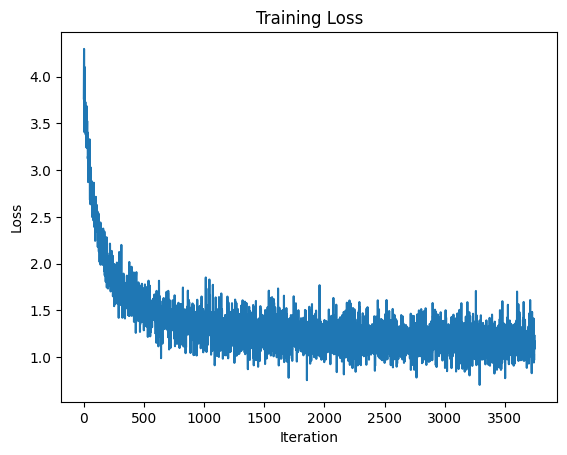

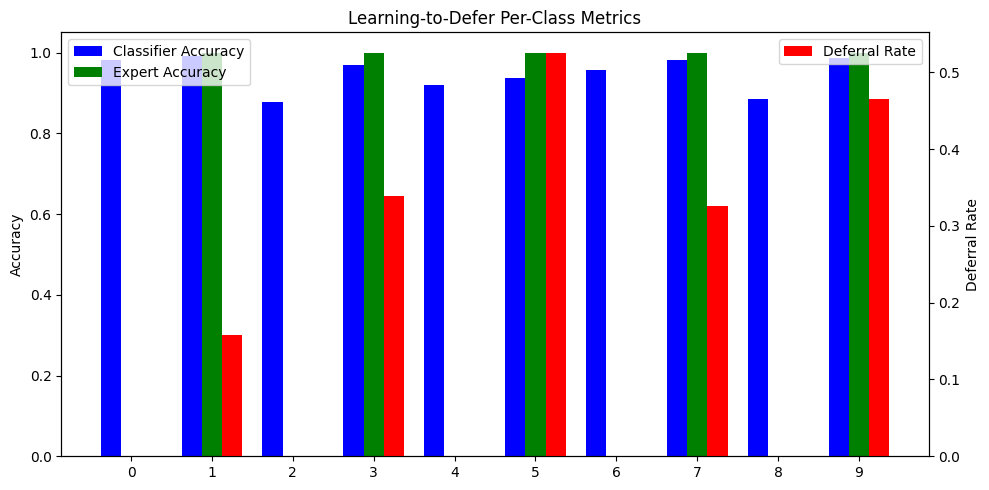

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from model import LogisticRegressionModule
from data import get_dataloaders, ExpertMNIST, get_dataloaders_with_val
from l2d_functionality.l2d_loss import L2D_Loss
from l2d_functionality.l2d_multi_objective import MultipleConstraintDGNP
from l2d_functionality.l2d_eval_combined import L2D_Eval_Combined 
import torchvision
import torchvision.transforms as transforms
import numpy as np
from torch.utils.data import random_split

# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Hyperparameters
input_dim = 28 * 28  # For MNIST (28x28 images flattened)
num_classes = 10
learning_rate = 0.0001
num_epochs = 5
l2_lambda = 0.0001
expert_prob = 0.9

# Output dimension includes the deferral class
output_dim = num_classes + 1  # One extra class for deferral
deferral_class_index = num_classes  # Index of the deferral class

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda tensor: torch.flatten(tensor))  # Flatten the image
])

train_dataset_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

val_frac = 0.2   # 20% for validation
n_total = len(train_dataset_raw)
n_val = int(val_frac * n_total)
n_train = n_total - n_val

train_dataset_raw, val_dataset_raw = random_split(train_dataset_raw, [n_train, n_val], generator=torch.Generator().manual_seed(0))

test_dataset_raw = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Instantiate the expert simulation
expert = ExpertMNIST(expert_prob)
# Helper to extract labels from a Subset
def labels_from_subset(subset):
    return torch.tensor([subset.dataset[idx][1] for idx in subset.indices])

train_labels = labels_from_subset(train_dataset_raw)
val_labels = labels_from_subset(val_dataset_raw)

expert_labels_train = torch.tensor([expert.expert_prediction(label) for label in train_labels])
expert_labels_val = torch.tensor([expert.expert_prediction(label) for label in val_labels])
expert_labels_test = torch.tensor([expert.expert_prediction(label) for _, label in test_dataset_raw])

# Instantiate the logistic regression model
model = LogisticRegressionModule(input_dim, output_dim, deferral_class_index, l2_lambda)

# Get the train and test data loaders
train_loader, val_loader, test_loader = get_dataloaders_with_val(
     train_dataset_raw, expert_labels_train,
     val_dataset_raw, expert_labels_val,
     test_dataset_raw, expert_labels_test
)

# Instantiate L2D loss function
l2d_loss_fn = L2D_Loss(num_classes)

# Set up optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set model to training mode

    for images, labels, expert_labels_batch in train_loader:
        outputs = model(images)
        
        # Compute the L2D loss
        loss = l2d_loss_fn.loss_fn(outputs, labels, expert_labels_batch, deferral_class_index, param_type="softmax")
        loss += model.l2_regularization()  # Add L2 regularization
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}")


# loss plot
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")

dgnp = MultipleConstraintDGNP(model=model, num_classes=num_classes, device='cpu')

delta = 0.20 # percentage of maximum deferral 
k_hat, p_hat = dgnp.fit_on_validation(val_loader, deferral_class_index=deferral_class_index, delta=delta, grid_min=-10, grid_max=10, grid_size=2000)
final_preds, raw_preds, defer_idx, true_labels, expert_labels_out = dgnp.apply_to_loader(test_loader, deferral_class_index=deferral_class_index, use_expert_at_test=True)

# Evaluate as before 
l2d_eval = L2D_Eval_Combined(num_classes, true_labels=true_labels, predicted_labels=final_preds, defer_idx=defer_idx)
print("Overall metrics:")
l2d_eval.model_report()
print("\nPer-Class Evaluation Metrics:")
l2d_eval.per_class_report()

l2d_eval.visualize_metrics("with_deferral_metrics.png")

Epoch 1/5, Loss: 1.2621442079544067
Epoch 2/5, Loss: 1.1908336877822876
Epoch 3/5, Loss: 0.9892863035202026
Epoch 4/5, Loss: 1.2141269445419312
Epoch 5/5, Loss: 1.2413426637649536
Overall metrics:
Classifier Accuracy (excl. deferrals): 1.0000
Expert Deferral Accuracy: 0.5416
Deferral Rate: 0.8931
Overall Accuracy: 0.5906

Per-Class Evaluation Metrics:
Class 0: Classifier Acc: 1.0000, Expert Acc: 0.0000, Deferral Rate: 0.6102
Class 1: Classifier Acc: 0.0000, Expert Acc: 0.9048, Deferral Rate: 1.0000
Class 2: Classifier Acc: 1.0000, Expert Acc: 0.0000, Deferral Rate: 0.7452
Class 3: Classifier Acc: 0.0000, Expert Acc: 0.9406, Deferral Rate: 1.0000
Class 4: Classifier Acc: 1.0000, Expert Acc: 0.0000, Deferral Rate: 0.9134
Class 5: Classifier Acc: 0.0000, Expert Acc: 0.9540, Deferral Rate: 1.0000
Class 6: Classifier Acc: 1.0000, Expert Acc: 0.0000, Deferral Rate: 0.7296
Class 7: Classifier Acc: 0.0000, Expert Acc: 0.9805, Deferral Rate: 1.0000
Class 8: Classifier Acc: 1.0000, Expert Acc: 0

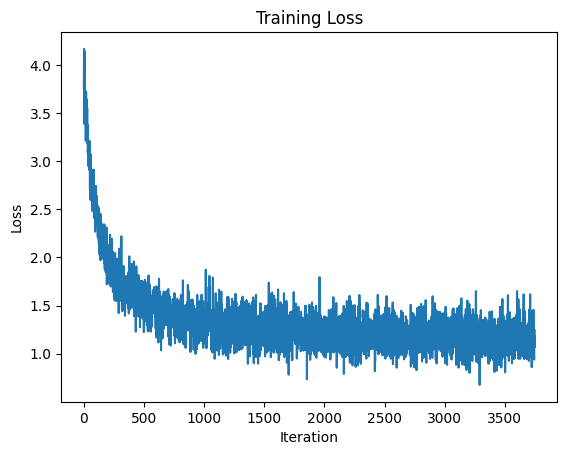

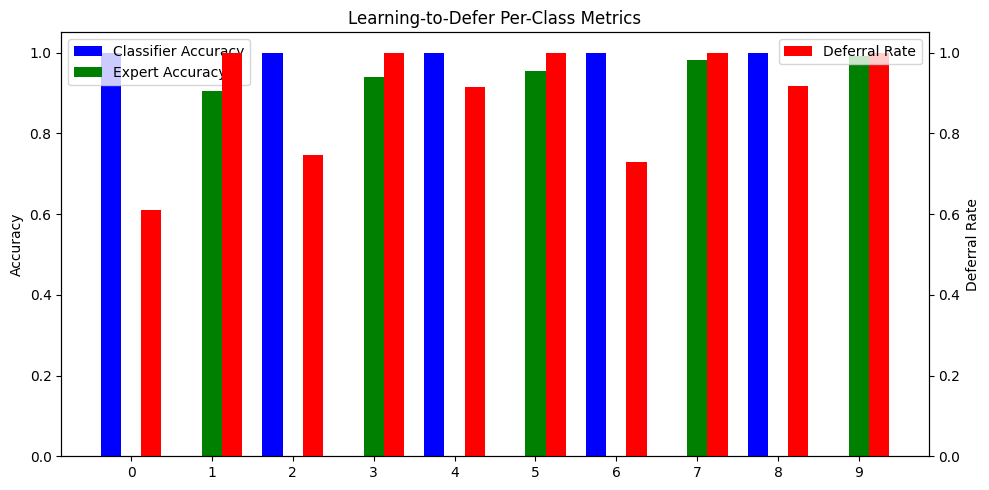

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from model import LogisticRegressionModule
from data import get_dataloaders, ExpertMNIST, get_dataloaders_with_val
from l2d_functionality.l2d_loss import L2D_Loss
from l2d_functionality.l2d_multi_objective import MultipleConstraintDGNP
from l2d_functionality.l2d_eval_combined import L2D_Eval_Combined 
import torchvision
import torchvision.transforms as transforms
import numpy as np
from torch.utils.data import random_split

# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Hyperparameters
input_dim = 28 * 28  # For MNIST (28x28 images flattened)
num_classes = 10
learning_rate = 0.0001
num_epochs = 5
l2_lambda = 0.0001
expert_prob = 0.9

# Output dimension includes the deferral class
output_dim = num_classes + 1  # One extra class for deferral
deferral_class_index = num_classes  # Index of the deferral class

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda tensor: torch.flatten(tensor))  # Flatten the image
])

train_dataset_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

val_frac = 0.2   # 20% for validation
n_total = len(train_dataset_raw)
n_val = int(val_frac * n_total)
n_train = n_total - n_val

train_dataset_raw, val_dataset_raw = random_split(train_dataset_raw, [n_train, n_val], generator=torch.Generator().manual_seed(0))

test_dataset_raw = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Instantiate the expert simulation
expert = ExpertMNIST(expert_prob)
# Helper to extract labels from a Subset
def labels_from_subset(subset):
    return torch.tensor([subset.dataset[idx][1] for idx in subset.indices])

train_labels = labels_from_subset(train_dataset_raw)
val_labels = labels_from_subset(val_dataset_raw)

expert_labels_train = torch.tensor([expert.expert_prediction(label) for label in train_labels])
expert_labels_val = torch.tensor([expert.expert_prediction(label) for label in val_labels])
expert_labels_test = torch.tensor([expert.expert_prediction(label) for _, label in test_dataset_raw])

# Instantiate the logistic regression model
model = LogisticRegressionModule(input_dim, output_dim, deferral_class_index, l2_lambda)

# Get the train and test data loaders
train_loader, val_loader, test_loader = get_dataloaders_with_val(
     train_dataset_raw, expert_labels_train,
     val_dataset_raw, expert_labels_val,
     test_dataset_raw, expert_labels_test
)

# Instantiate L2D loss function
l2d_loss_fn = L2D_Loss(num_classes)

# Set up optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set model to training mode

    for images, labels, expert_labels_batch in train_loader:
        outputs = model(images)
        
        # Compute the L2D loss
        loss = l2d_loss_fn.loss_fn(outputs, labels, expert_labels_batch, deferral_class_index, param_type="softmax")
        loss += model.l2_regularization()  # Add L2 regularization
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}")


# loss plot
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")

dgnp = MultipleConstraintDGNP(model=model, num_classes=num_classes, device='cpu')

delta = 0.99 # percentage of maximum deferral 
k_hat, p_hat = dgnp.fit_on_validation(val_loader, deferral_class_index=deferral_class_index, delta=delta, grid_min=-10, grid_max=10, grid_size=2000)
final_preds, raw_preds, defer_idx, true_labels, expert_labels_out = dgnp.apply_to_loader(test_loader, deferral_class_index=deferral_class_index, use_expert_at_test=True)

# Evaluate as before 
l2d_eval = L2D_Eval_Combined(num_classes, true_labels=true_labels, predicted_labels=final_preds, defer_idx=defer_idx)
print("Overall metrics:")
l2d_eval.model_report()
print("\nPer-Class Evaluation Metrics:")
l2d_eval.per_class_report()

l2d_eval.visualize_metrics("with_deferral_metrics.png")